In [17]:
!pip install kagglehub
import kagglehub
path = kagglehub.dataset_download("vishala28/swat-dataset-secure-water-treatment-system")
print(f"Dataset downloaded to: {path}")


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset downloaded to: C:\Users\Dax\.cache\kagglehub\datasets\vishala28\swat-dataset-secure-water-treatment-system\versions\3


In [18]:
# Install SHAP if missing in the Colab environment
!pip install "shap<0.50" matplotlib networkx scikit-learn tensorflow "numpy<2" pyarrow --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import shap
import warnings
import gc
import os

warnings.filterwarnings('ignore')

# Deep Learning & ML
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

# Optimize memory and set plotting styles
tf.keras.backend.clear_session()
plt.rcParams['figure.figsize'] = (12, 5)
plt.style.use('dark_background')
COLORS = {'normal': '#2ecc71', 'attack': '#e74c3c', 'layer1': '#3498db', 'layer2': '#f1c40f', 'layer3': '#9b59b6'}

print(f"TensorFlow Version: {tf.__version__}")
# Check if Colab GPU is active
if len(tf.config.list_physical_devices('GPU')) > 0:
    print("✅ GPU is active and ready.")
else:
    print("⚠️ WARNING: GPU not found. Go to Runtime > Change runtime type and select T4 GPU.")

TensorFlow Version: 2.21.0
⚠️ WARNING: GPU not found. Go to Runtime > Change runtime type and select T4 GPU.



[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# ==========================================
# ⚙️ USER CONFIGURATION: DATASET UPLOAD
# ==========================================
# Option 1: If your files are in the Colab filesystem (uploaded via the folder icon on the left)
PATH_NORMAL = r'C:\Users\Dax\.cache\kagglehub\datasets\vishala28\swat-dataset-secure-water-treatment-system\versions\3\normal.csv'
PATH_ATTACK = r'C:\Users\Dax\.cache\kagglehub\datasets\vishala28\swat-dataset-secure-water-treatment-system\versions\3\attack.csv'

# --- OR ---
# Option 2: If mounting Google Drive (Uncomment the two lines below)
# from google.colab import drive
# drive.mount('/content/drive')
# PATH_NORMAL = '/content/drive/MyDrive/your_path/normal_data.csv'

print("Loading original dataset...")
try:
    df_normal = pd.read_csv(PATH_NORMAL)
    df_attack = pd.read_csv(PATH_ATTACK)

    df_normal['Attack_Label'] = 0
    df_attack['Attack_Label'] = 1

    # Colab RAM limitation safeguard: Sample data if it exceeds 200,000 rows
    MAX_ROWS = 200000
    if len(df_normal) > MAX_ROWS:
        print(f"Downsampling normal data from {len(df_normal)} to {MAX_ROWS} to prevent Colab RAM crash...")
        df_normal = df_normal.sample(MAX_ROWS, random_state=42).reset_index(drop=True)

    df = pd.concat([df_normal, df_attack], ignore_index=True)

    # --- NEW CLEANING STEP TO PREVENT 'NaN' LOSS ---
    print("Cleaning dirty data (handling missing/infinite values)...")
    df = df.replace([np.inf, -np.inf], np.nan) # Convert infinities to NaN
    df = df.ffill().fillna(0) # Forward fill missing data, then replace any leftovers with 0

    print(f"✅ Data loaded and cleaned successfully. Total shape: {df.shape}")

except FileNotFoundError:
    print(f"❌ ERROR: Could not find the CSV files. Please upload them to Colab.")
    raise

# ==========================================
# ⚙️ USER CONFIGURATION: FEATURE SELECTION
# ==========================================
# List the exact column names from your CSV that represent physical sensors.
# The AI Defender will monitor these.
SENSOR_COLUMNS = [
    'FIT101',  # Flow Indicator Transmitter (Inlet flow)
    'LIT101',  # Level Indicator Transmitter (Tank level)
    'MV101',   # Motorized Valve (Controls water inflow)
    'P101',    # Raw Water Pump 1
    'P102'     # Raw Water Pump 2 (Backup)
]

# Ensure the specified columns actually exist in your dataframe
missing_cols = [col for col in SENSOR_COLUMNS if col not in df.columns]
if missing_cols:
    print(f"⚠️ Warning: These columns were not found in your CSV: {missing_cols}")
    # Fallback: Auto-select numeric columns if user config fails
    print("Auto-selecting all numeric columns for modeling...")
    SENSOR_COLUMNS = df.select_dtypes(include=[np.number]).columns.drop('Attack_Label').tolist()

print(f"Features selected for AI monitoring: {len(SENSOR_COLUMNS)} sensors.")

Loading original dataset...
Downsampling normal data from 1387098 to 200000 to prevent Colab RAM crash...
Cleaning dirty data (handling missing/infinite values)...
✅ Data loaded and cleaned successfully. Total shape: (254621, 54)
⚠️ Warning: These columns were not found in your CSV: ['MV101']
Auto-selecting all numeric columns for modeling...
Features selected for AI monitoring: 51 sensors.


In [20]:
print("Preprocessing and creating time-series sequences...")

# Scale Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[SENSOR_COLUMNS].values).astype(np.float32)

# Sequence Generator
SEQ_LENGTH = 5
def create_sequences(data, seq_length):
    n = len(data) - seq_length + 1
    seqs = np.zeros((n, seq_length, data.shape[1]), dtype=np.float32)
    for i in range(n): seqs[i] = data[i:i+seq_length]
    return seqs

X_seq = create_sequences(X_scaled, SEQ_LENGTH)
y_labels = df['Attack_Label'].values[SEQ_LENGTH-1:]

# Split logic: Train purely on normal data, test on mixed data
normal_indices = np.where(y_labels == 0)[0]
attack_indices = np.where(y_labels == 1)[0]

# Take 80% of normal data for training
train_size = int(len(normal_indices) * 0.8)
train_idx = normal_indices[:train_size]

# The rest (20% normal + ALL attacks) goes to testing
test_idx = np.concatenate([normal_indices[train_size:], attack_indices])
np.random.shuffle(test_idx) # Shuffle test set

X_train_seq = X_seq[train_idx]
X_test_seq = X_seq[test_idx]
y_test = y_labels[test_idx]

print(f"✅ Training sequences (Normal Only): {X_train_seq.shape}")
print(f"✅ Testing sequences (Mixed): {X_test_seq.shape}")

# Free RAM
del df, X_scaled, X_seq
gc.collect()

Preprocessing and creating time-series sequences...
✅ Training sequences (Normal Only): (159996, 5, 51)
✅ Testing sequences (Mixed): (94621, 5, 51)


0

Constructing Custom SWaT CPS Threat Graph...


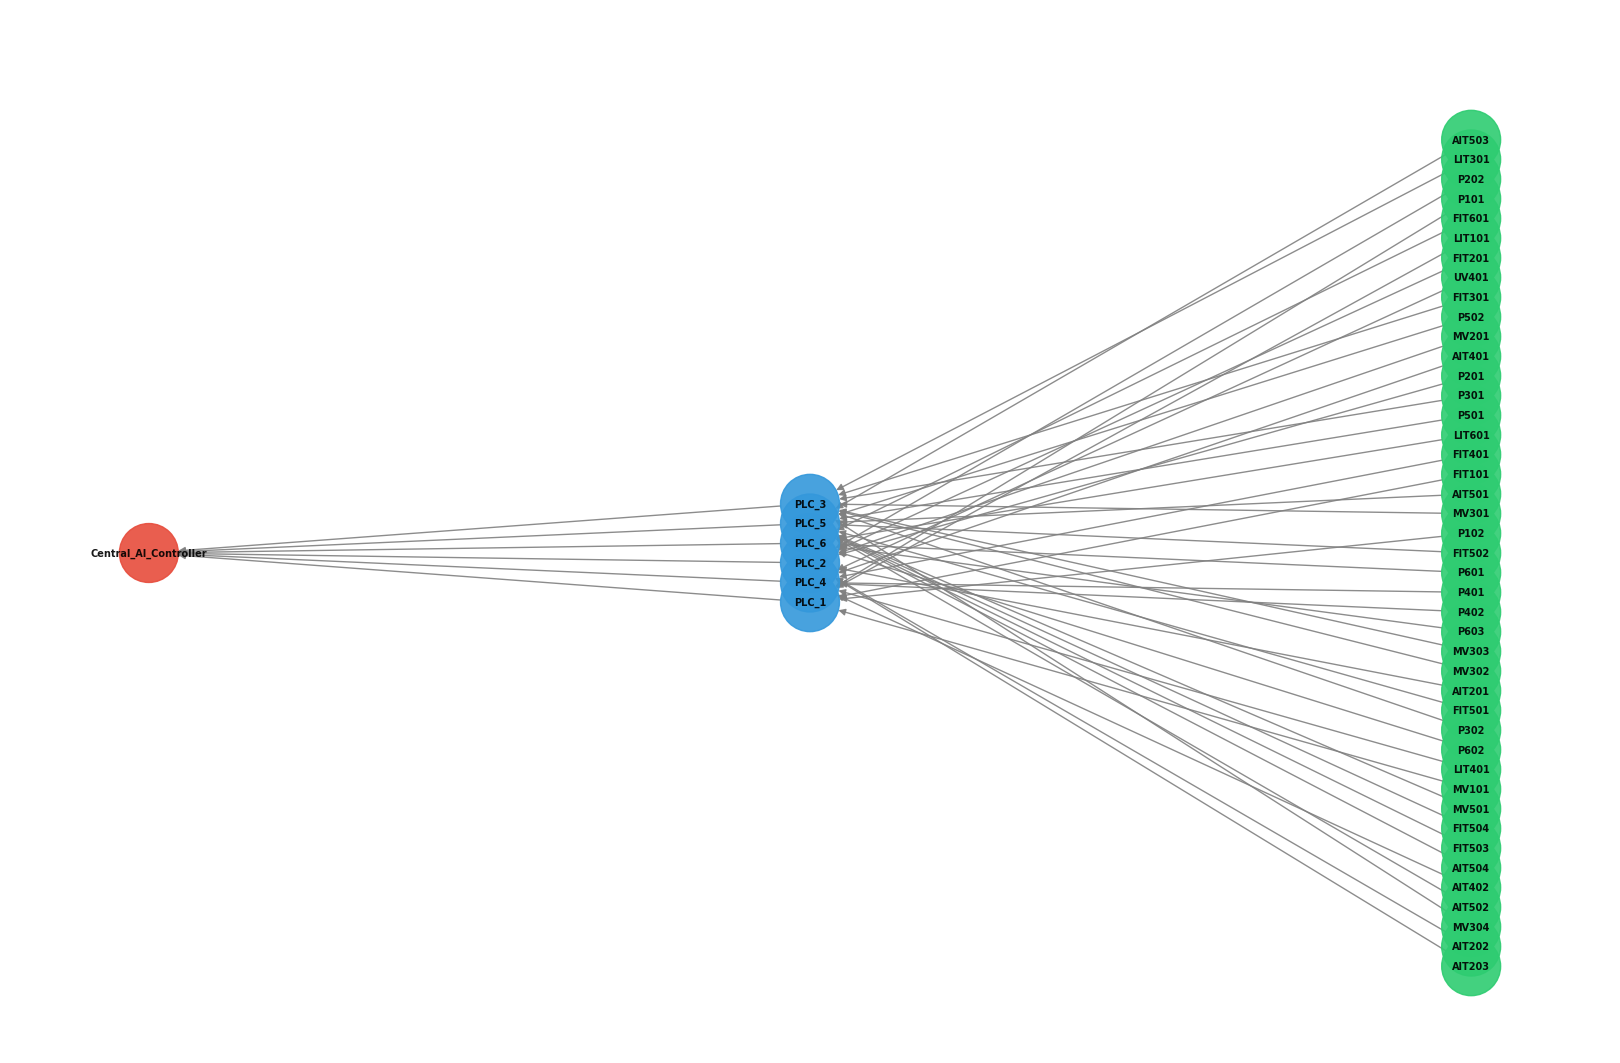

In [29]:
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# ⚙️ USER CONFIGURATION: SWAT TOPOLOGY
# ==========================================
print("Constructing Custom SWaT CPS Threat Graph...")
G = nx.DiGraph()

# Original mapping based on the 6 Stages of the SWaT Testbed
TOPOLOGY_MAPPING = {
    # STAGE 1: Raw Water Intake
    'FIT101': 'PLC_1', 'LIT101': 'PLC_1', 'MV101': 'PLC_1', 'P101': 'PLC_1', 'P102': 'PLC_1',
    # STAGE 2: Pre-Treatment (Chemical Dosing)
    'AIT201': 'PLC_2', 'AIT202': 'PLC_2', 'AIT203': 'PLC_2', 'FIT201': 'PLC_2', 'MV201': 'PLC_2', 'P201': 'PLC_2', 'P202': 'PLC_2',
    # STAGE 3: Ultrafiltration
    'FIT301': 'PLC_3', 'LIT301': 'PLC_3', 'MV301': 'PLC_3', 'MV302': 'PLC_3', 'MV303': 'PLC_3', 'MV304': 'PLC_3', 'P301': 'PLC_3', 'P302': 'PLC_3',
    # STAGE 4: De-chlorination
    'AIT401': 'PLC_4', 'AIT402': 'PLC_4', 'FIT401': 'PLC_4', 'LIT401': 'PLC_4', 'P401': 'PLC_4', 'P402': 'PLC_4', 'UV401': 'PLC_4',
    # STAGE 5: Reverse Osmosis
    'AIT501': 'PLC_5', 'AIT502': 'PLC_5', 'AIT503': 'PLC_5', 'AIT504': 'PLC_5', 'FIT501': 'PLC_5', 'FIT502': 'PLC_5', 'FIT503': 'PLC_5', 'FIT504': 'PLC_5', 'P501': 'PLC_5', 'P502': 'PLC_5', 'MV501': 'PLC_5',
    # STAGE 6: Distribution
    'FIT601': 'PLC_6', 'LIT601': 'PLC_6', 'P601': 'PLC_6', 'P602': 'PLC_6', 'P603': 'PLC_6'
}

# --- Add Nodes with Layer Attributes ---
# Physical Layer (Sensors/Actuators)
for component in TOPOLOGY_MAPPING.keys():
    G.add_node(component, layer='Physical')

# Network Layer (PLCs)
plcs = list(set(TOPOLOGY_MAPPING.values()))
for plc in plcs:
    G.add_node(plc, layer='Network')

# AI Layer (Central Defender)
G.add_node('Central_AI_Controller', layer='AI')

# --- Draw Edges (Information Flow) ---
# Edges from Sensors to PLCs
for sensor, plc in TOPOLOGY_MAPPING.items():
    G.add_edge(sensor, plc)

# Edges from PLCs to Central AI
for plc in plcs:
    G.add_edge(plc, 'Central_AI_Controller')

# ==========================================
# 🎨 VISUALIZATION SETTINGS
# ==========================================
plt.figure(figsize=(16, 10))

# Use multipartite layout to separate layers vertically
pos = nx.multipartite_layout(G, subset_key="layer")

# Define layer colors
COLORS = {
    'Physical': '#2ecc71', # Green
    'Network': '#3498db',  # Blue
    'AI': '#e74c3c'        # Red
}

node_colors = [COLORS[G.nodes[n]['layer']] for n in G.nodes]

# Draw the graph
nx.draw(G, pos, 
        with_labels=True, 
        node_color=node_colors, 
        node_size=1800,
        font_size=7, 
        font_color='black', 
        font_weight='bold', 
        arrows=True,
        edge_color='gray',
        alpha=0.9)

# Legend/Title
plt.title("SWaT Hierarchical Threat Model: Sensors → PLCs → AI", fontsize=16, pad=20)
plt.show()

In [22]:
# ==========================================
# BUILD & TRAIN THE LSTM AUTOENCODER (DEFENDER)
# ==========================================
print("Building LSTM Autoencoder (Defender)...")

n_features = len(SENSOR_COLUMNS)

# Encoder
inputs = keras.Input(shape=(SEQ_LENGTH, n_features))
encoded = layers.LSTM(64, activation='relu', return_sequences=True)(inputs)
encoded = layers.LSTM(32, activation='relu', return_sequences=False)(encoded)

# Decoder
decoded = layers.RepeatVector(SEQ_LENGTH)(encoded)
decoded = layers.LSTM(32, activation='relu', return_sequences=True)(decoded)
decoded = layers.LSTM(64, activation='relu', return_sequences=True)(decoded)
outputs = layers.TimeDistributed(layers.Dense(n_features))(decoded)

defender = Model(inputs, outputs)
defender.compile(optimizer='adam', loss='mse')

defender.summary()

# Train the defender on NORMAL data only (unsupervised anomaly detection)
print("\nTraining the Defender on normal data...")
history = defender.fit(
    X_train_seq, X_train_seq,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

# Calculate anomaly detection threshold from training reconstruction error
print("\nCalculating anomaly detection threshold...")
train_preds = defender.predict(X_train_seq, batch_size=512, verbose=0)
train_mse = np.mean(np.square(X_train_seq - train_preds), axis=(1, 2))
threshold_95 = np.percentile(train_mse, 95)
print(f"\u2705 Anomaly Detection Threshold (95th percentile): {threshold_95:.6f}")
print(f"\u2705 Defender model ready.")


Building LSTM Autoencoder (Defender)...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5, 51)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 5, 64)          │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 5, 32)          │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 5, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 51)          │         3,315 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,579 (306.95 KB)

 Trainable params: 78,579 (306.95 KB)

 Non-trainable params: 0 (0.00 B)


Training the Defender on normal data...
Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 0.3736 - val_loss: 0.2552
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 0.2365 - val_loss: 0.1869
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 0.1929 - val_loss: 0.1617
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.1667 - val_loss: 0.1505
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - loss: 0.2369 - val_loss: 0.1573
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 0.2681 - val_loss: 0.1371
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 0.1532 - val_loss: 0.1205
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 0.1283 - val_loss: 0.1036
Epoch 9/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 0.1418 - val_loss: 0.0932
Epoch 10/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 0.1047 - val_loss: 0.0880

Calculating anomaly detection threshold...
✅ Anomaly Detection Threshold (95t

Generating Comprehensive Performance Graphs...


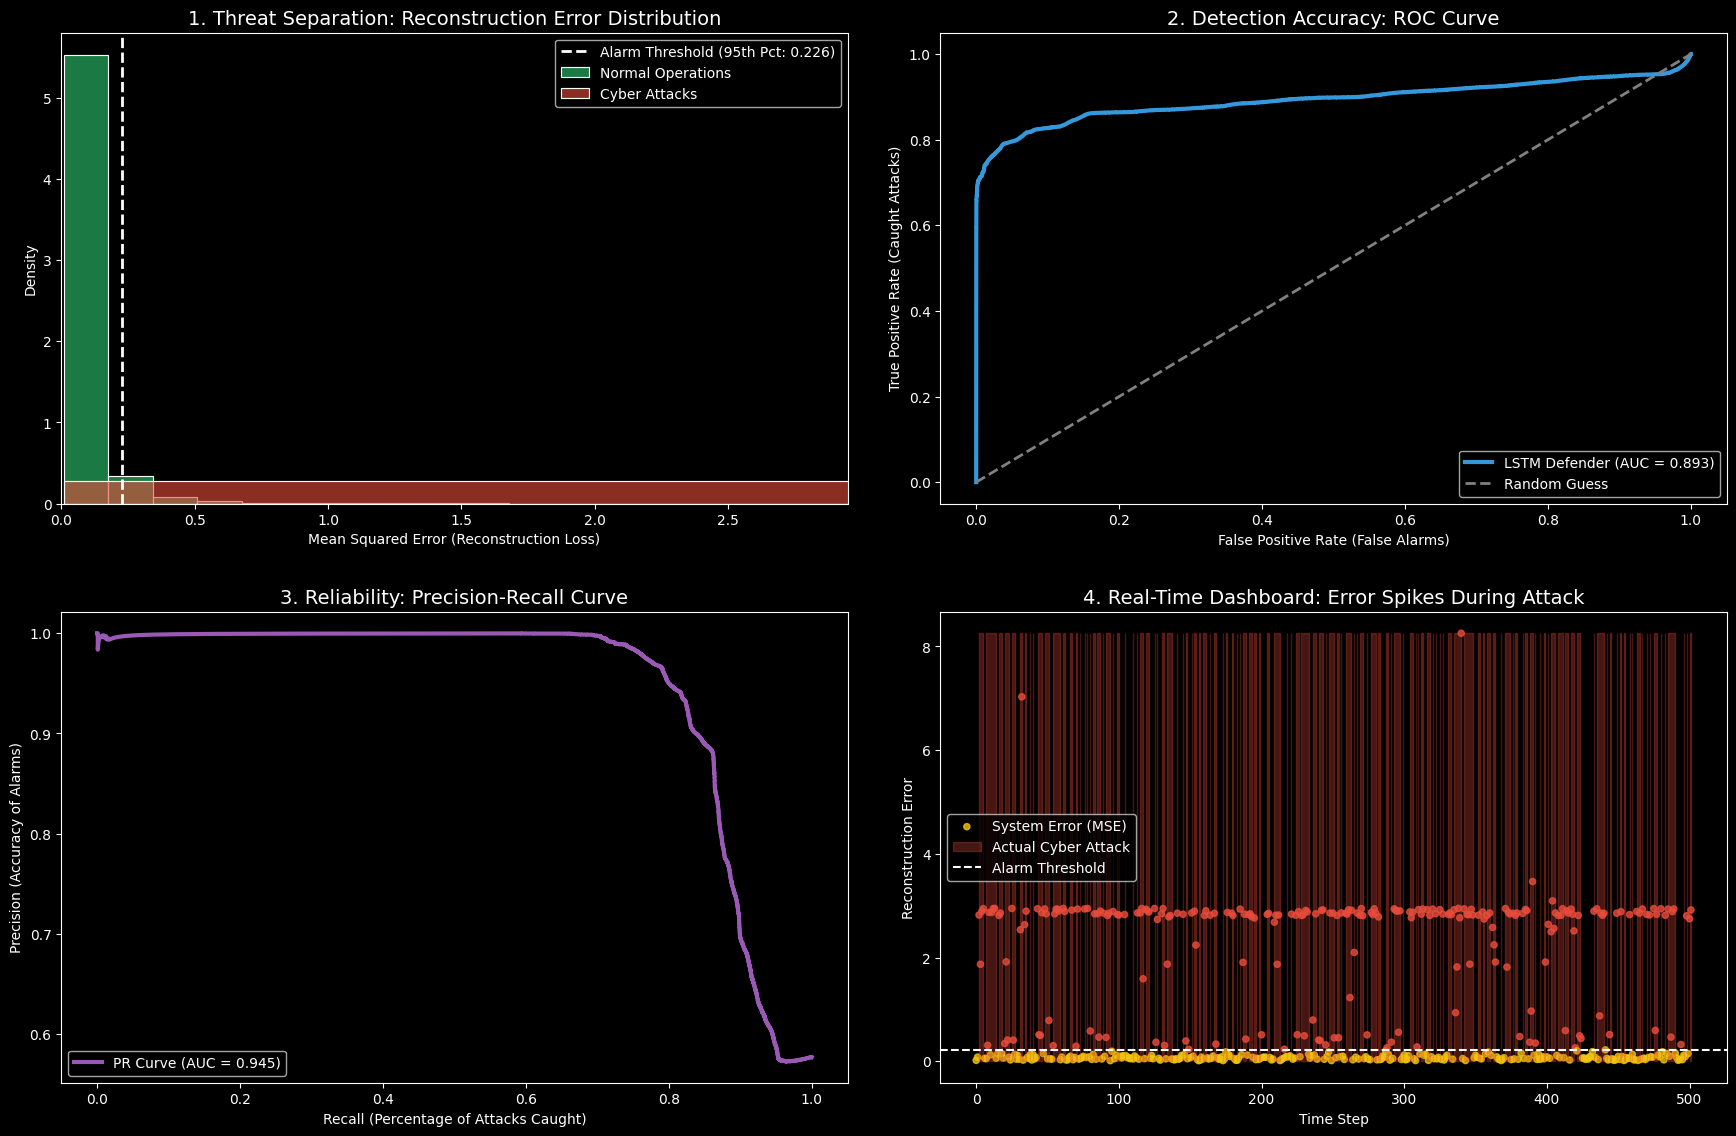

In [23]:
# ==========================================
# LSTM DEFENDER: COMPREHENSIVE VISUAL REPORT
# ==========================================
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
import seaborn as sns

print("Generating Comprehensive Performance Graphs...")

# 1. Get Predictions on the mixed Test Set
test_preds = defender.predict(X_test_seq, batch_size=512, verbose=0)
test_mse = np.mean(np.square(X_test_seq - test_preds), axis=(1, 2))

# 2. Setup Figure Canvas
fig = plt.figure(figsize=(18, 12))
plt.style.use('dark_background')

# ---------------------------------------------------------
# GRAPH 1: Reconstruction Error Distribution (Histogram)
# ---------------------------------------------------------
# This proves how well your AI separates normal data from attacks
ax1 = plt.subplot(2, 2, 1)
sns.histplot(test_mse[y_test == 0], bins=50, color=COLORS['normal'], label='Normal Operations', stat='density', alpha=0.6, ax=ax1)
sns.histplot(test_mse[y_test == 1], bins=50, color=COLORS['attack'], label='Cyber Attacks', stat='density', alpha=0.6, ax=ax1)
ax1.axvline(threshold_95, color='white', linestyle='--', linewidth=2, label=f'Alarm Threshold (95th Pct: {threshold_95:.3f})')
ax1.set_title("1. Threat Separation: Reconstruction Error Distribution", fontsize=14, color='white')
ax1.set_xlabel("Mean Squared Error (Reconstruction Loss)")
ax1.set_ylabel("Density")
# Zoom in on the critical boundary to prevent massive outlier distortion
ax1.set_xlim(0, np.percentile(test_mse, 98))
ax1.legend()

# ---------------------------------------------------------
# GRAPH 2: ROC Curve (Receiver Operating Characteristic)
# ---------------------------------------------------------
# Shows the trade-off between catching attacks and triggering false alarms
ax2 = plt.subplot(2, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test, test_mse)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color=COLORS['layer1'], lw=3, label=f'LSTM Defender (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')
ax2.set_title("2. Detection Accuracy: ROC Curve", fontsize=14, color='white')
ax2.set_xlabel("False Positive Rate (False Alarms)")
ax2.set_ylabel("True Positive Rate (Caught Attacks)")
ax2.legend(loc="lower right")

# ---------------------------------------------------------
# GRAPH 3: Precision-Recall Curve
# ---------------------------------------------------------
# Critical for anomaly detection where normal data heavily outweighs attack data
ax3 = plt.subplot(2, 2, 3)
precision, recall, pr_thresholds = precision_recall_curve(y_test, test_mse)
pr_auc = auc(recall, precision)

ax3.plot(recall, precision, color=COLORS['layer3'], lw=3, label=f'PR Curve (AUC = {pr_auc:.3f})')
ax3.set_title("3. Reliability: Precision-Recall Curve", fontsize=14, color='white')
ax3.set_xlabel("Recall (Percentage of Attacks Caught)")
ax3.set_ylabel("Precision (Accuracy of Alarms)")
ax3.legend(loc="lower left")

# ---------------------------------------------------------
# GRAPH 4: Time-Series Anomaly Overlay
# ---------------------------------------------------------
# A real-world view of the data over time with attacks highlighted
ax4 = plt.subplot(2, 2, 4)

# Plot a 1000-timestep slice that contains an attack
attack_indices = np.where(y_test == 1)[0]
if len(attack_indices) > 0:
    start_idx = max(0, attack_indices[0] - 500)
    end_idx = min(len(y_test), attack_indices[0] + 500)

    # Plot the reconstruction error over time
    time_steps = range(start_idx, end_idx)
    # Changed to scatter plot for better visual understanding
    mse_slice = test_mse[start_idx:end_idx]
    point_colors = np.where(mse_slice > threshold_95, COLORS['attack'], COLORS['layer2'])
    ax4.scatter(time_steps, mse_slice, color=point_colors, label='System Error (MSE)', s=20, alpha=0.8)

    # Shade the actual attack windows in red
    ax4.fill_between(time_steps, 0, max(test_mse[start_idx:end_idx]),
                     where=(y_test[start_idx:end_idx] == 1),
                     color=COLORS['attack'], alpha=0.3, label='Actual Cyber Attack')

    # Draw the threshold line
    ax4.axhline(threshold_95, color='white', linestyle='--', label='Alarm Threshold')

    ax4.set_title("4. Real-Time Dashboard: Error Spikes During Attack", fontsize=14, color='white')
    ax4.set_xlabel("Time Step")
    ax4.set_ylabel("Reconstruction Error")
    ax4.legend()
else:
    ax4.text(0.5, 0.5, "No attacks in test set to display", ha='center', color='white')

plt.tight_layout(pad=3.0)
plt.show()

Calculating Metrics based on Anomaly Detection Threshold...
Accuracy:  0.8610
Precision: 0.9563
Recall:    0.7956
F1 Score:  0.8686



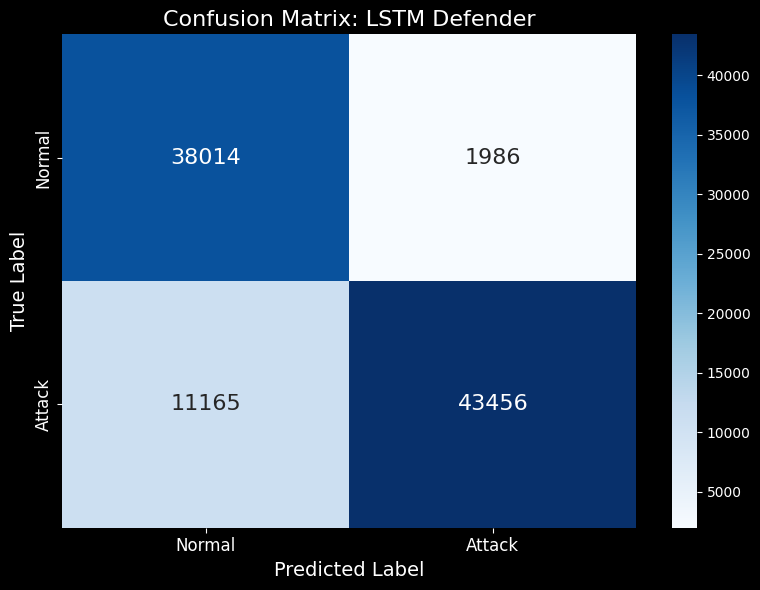

In [24]:
# ==========================================
# CONFUSION MATRIX & MODEL METRICS
# ==========================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

print("Calculating Metrics based on Anomaly Detection Threshold...")

# Convert MSE to binary predictions based on the 95th percentile threshold
y_pred = (test_mse > threshold_95).astype(int)

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}\n")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'],
            annot_kws={"size": 16})

plt.title("Confusion Matrix: LSTM Defender", color='white', fontsize=16)
plt.xlabel("Predicted Label", color='white', fontsize=14)
plt.ylabel("True Label", color='white', fontsize=14)
# Make ticks white to match dark background
plt.xticks(color='white', fontsize=12)
plt.yticks(color='white', fontsize=12)

plt.tight_layout()
plt.show()



STARTING EXTENDED CO-EVOLUTIONARY ARMS RACE (9 ROUNDS)

[ROUND 1]
-> Attacker evolving: Launching Stealth Variants (Epsilon 0.03)...
-> System Risk Score: 0.1840 (368/2000 attacks bypassed IDS)
-> Defender adapting and patching blind spots...

[ROUND 2]
-> Attacker evolving: Launching Stealth Variants (Epsilon 0.06)...
-> System Risk Score: 0.7640 (1528/2000 attacks bypassed IDS)
-> Defender adapting and patching blind spots...

[ROUND 3]
-> Attacker evolving: Launching Stealth Variants (Epsilon 0.09)...
-> System Risk Score: 0.7045 (1409/2000 attacks bypassed IDS)
-> Defender adapting and patching blind spots...

[ROUND 4]
-> Attacker evolving: Launching Stealth Variants (Epsilon 0.12)...
-> System Risk Score: 0.6400 (1280/2000 attacks bypassed IDS)
-> Defender adapting and patching blind spots...

[ROUND 5]
-> Attacker evolving: Launching Stealth Variants (Epsilon 0.15)...
-> System Risk Score: 0.0900 (180/2000 attacks bypassed IDS)
-> Defender adapting and patching blind spots...



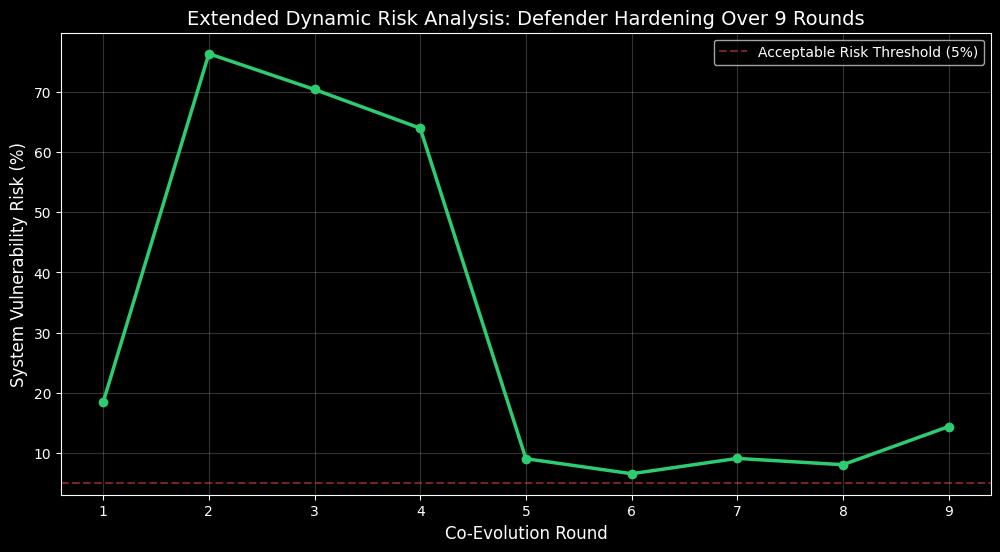

In [25]:
def generate_stealth_attack(model, base_sequences, epsilon):
    """FGSM Attacker: Uses gradients to generate invisible noise."""
    inputs = tf.convert_to_tensor(base_sequences, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(inputs)
        reconstructions = model(inputs)
        loss = tf.reduce_mean(tf.square(inputs - reconstructions))

    gradients = tape.gradient(loss, inputs)
    perturbation = epsilon * tf.sign(gradients)
    return (inputs + perturbation).numpy()

# ==========================================
# ⚙️ EXTENDED ARMS RACE CONFIGURATION
# ==========================================
ROUNDS = 9  # Increased from 4 to 10 rounds to let the defender win
system_risk_history = []

# Get a sample of actual attacks from your dataset to base the simulation on
attack_indices = np.where(y_test == 1)[0]
if len(attack_indices) == 0:
    raise ValueError("No attack data found in the test set. Cannot run simulation.")

# Limit to 2000 attacks for the simulation to prevent Colab GPU OOM
sample_size = min(2000, len(attack_indices))
actual_attacks_seq = X_test_seq[np.random.choice(attack_indices, sample_size, replace=False)]

print("\n" + "="*60)
print(f"STARTING EXTENDED CO-EVOLUTIONARY ARMS RACE ({ROUNDS} ROUNDS)")
print("="*60)

for round_num in range(1, ROUNDS + 1):
    print(f"\n[ROUND {round_num}]")

    # 1. THE ATTACK (Adversarial Engine)
    # We use 'min' to cap the epsilon at 0.25.
    # In the real world, if an attacker injects too much noise, physical alarms trip automatically.
    dynamic_epsilon = min(0.03 * round_num, 0.20)

    print(f"-> Attacker evolving: Launching Stealth Variants (Epsilon {dynamic_epsilon:.2f})...")
    stealth_attacks = generate_stealth_attack(defender, actual_attacks_seq, epsilon=dynamic_epsilon)

    # 2. EVALUATE PHYSICAL RISK
    stealth_preds = defender.predict(stealth_attacks, verbose=0)
    stealth_mse = np.mean(np.square(stealth_attacks - stealth_preds), axis=(1, 2))

    bypassed_count = np.sum(stealth_mse < threshold_95)
    system_risk = bypassed_count / len(stealth_attacks)
    system_risk_history.append(system_risk)

    print(f"-> System Risk Score: {system_risk:.4f} ({bypassed_count}/{len(stealth_attacks)} attacks bypassed IDS)")

    # 3. THE DEFENSE (Retraining)
    if round_num < ROUNDS:
        print("-> Defender adapting and patching blind spots...")
        # Train on a mix of normal data and the new stealth attacks
        retrain_x = np.vstack([X_train_seq[:3000], stealth_attacks])
        # We give the defender slightly more epochs (5 instead of 3) to learn the complex new attacks
        defender.fit(retrain_x, retrain_x, epochs=5, batch_size=128, verbose=0)

# Plot the Extended Arms Race Results
plt.figure(figsize=(12, 6))
plt.plot(range(1, ROUNDS + 1), [risk * 100 for risk in system_risk_history], marker='o', color=COLORS['normal'], linewidth=2.5)

# Add a trendline to show the defender winning
plt.axhline(y=5, color=COLORS['attack'], linestyle='--', alpha=0.5, label="Acceptable Risk Threshold (5%)")

plt.title(f"Extended Dynamic Risk Analysis: Defender Hardening Over {ROUNDS} Rounds", color='white', fontsize=14)
plt.xlabel("Co-Evolution Round", color='white', fontsize=12)
plt.ylabel("System Vulnerability Risk (%)", color='white', fontsize=12)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Initializing SHAP for Attack Surface Explainability...
Generating SHAP explanations for 10 attacks...

Processing attack 1/10 (index=2)...


  0%|          | 0/1 [00:00<?, ?it/s]

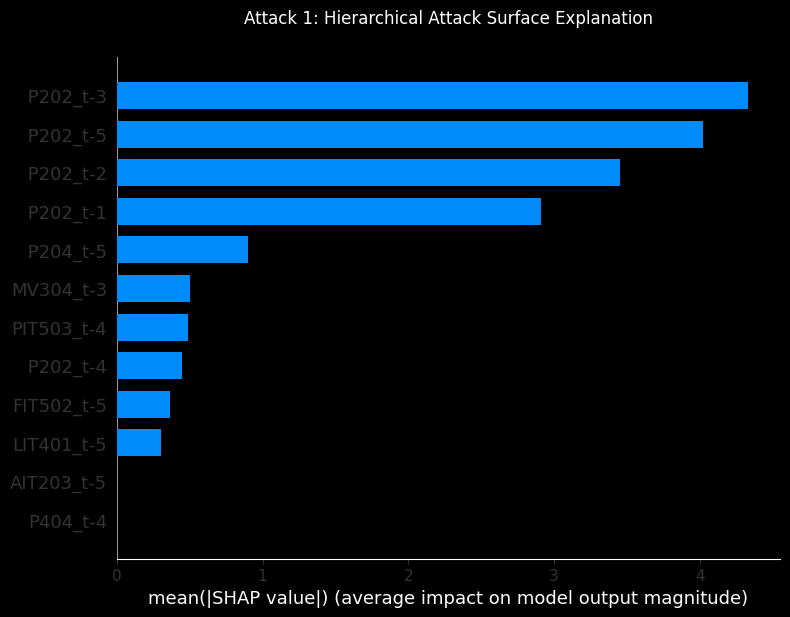

Processing attack 2/10 (index=3)...


  0%|          | 0/1 [00:00<?, ?it/s]

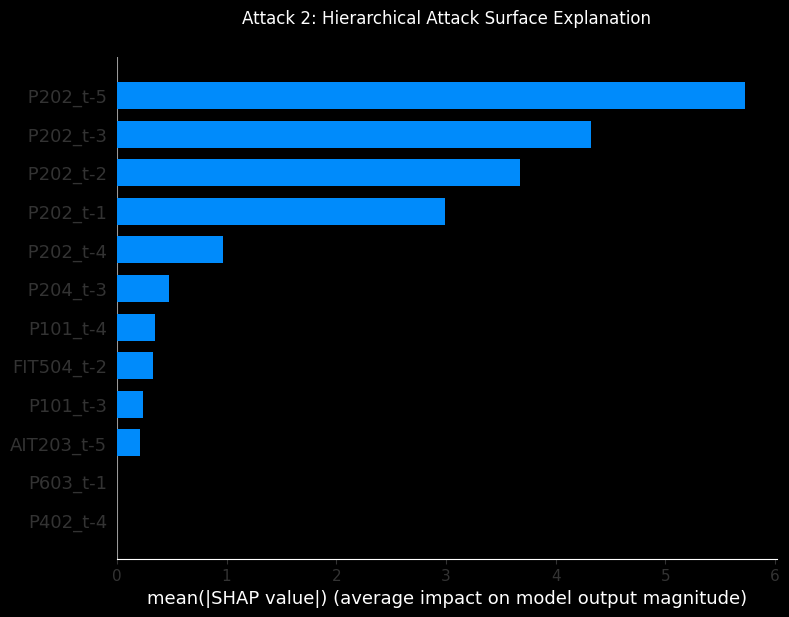

Processing attack 3/10 (index=4)...


  0%|          | 0/1 [00:00<?, ?it/s]

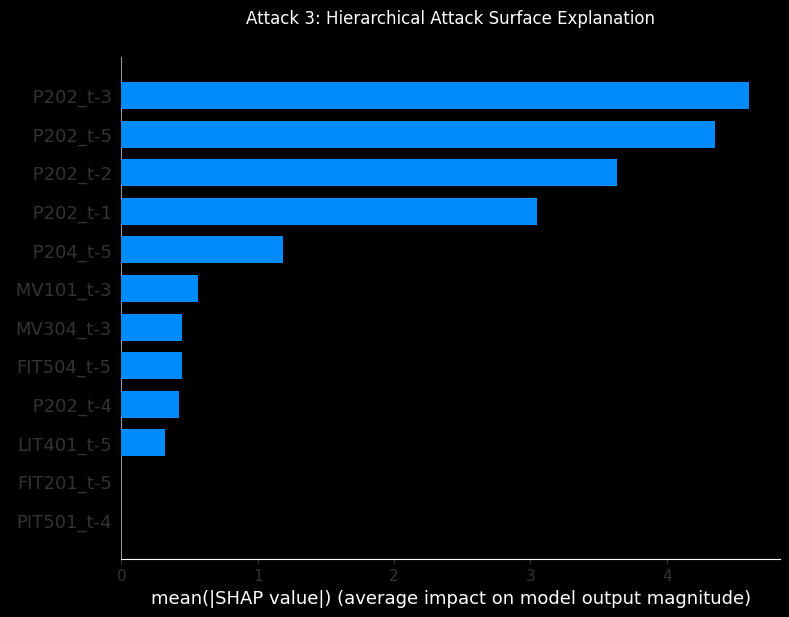

Processing attack 4/10 (index=5)...


  0%|          | 0/1 [00:00<?, ?it/s]

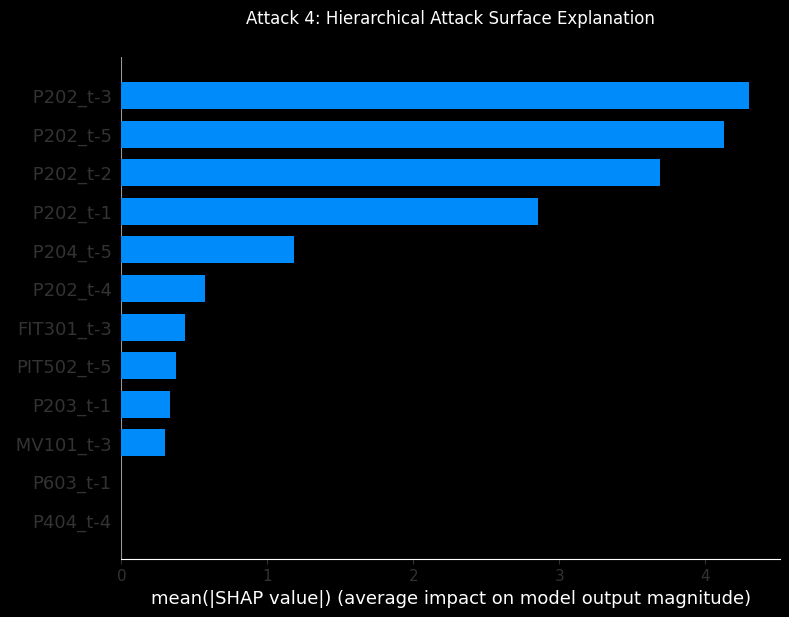

Processing attack 5/10 (index=7)...


  0%|          | 0/1 [00:00<?, ?it/s]

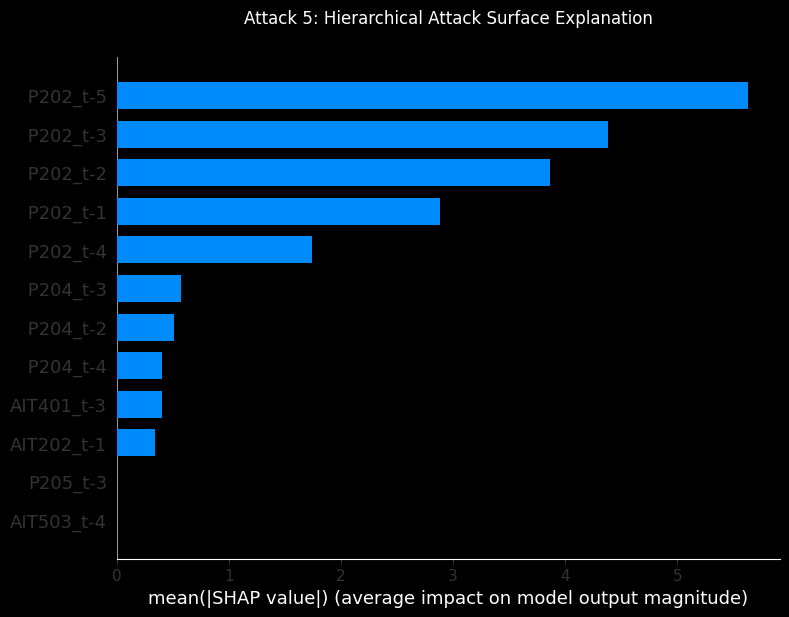

Processing attack 6/10 (index=8)...


  0%|          | 0/1 [00:00<?, ?it/s]

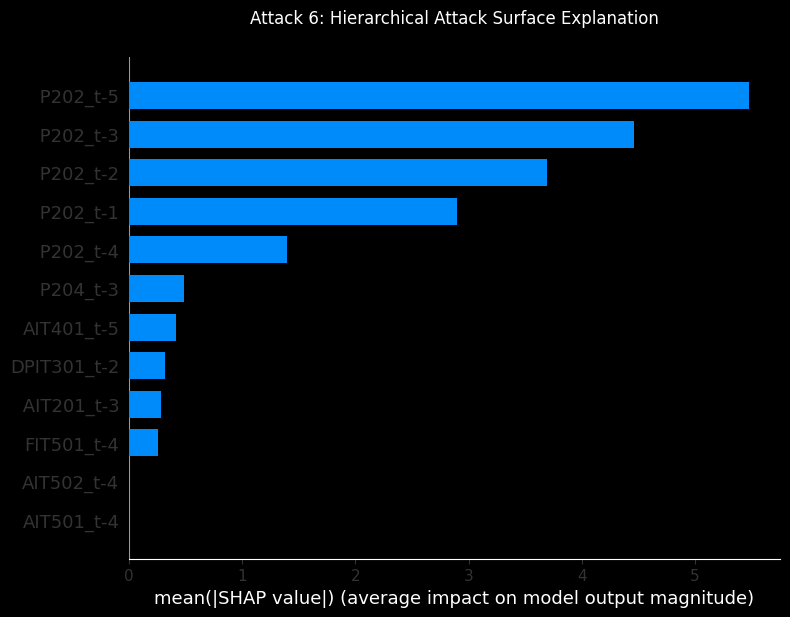

Processing attack 7/10 (index=9)...


  0%|          | 0/1 [00:00<?, ?it/s]

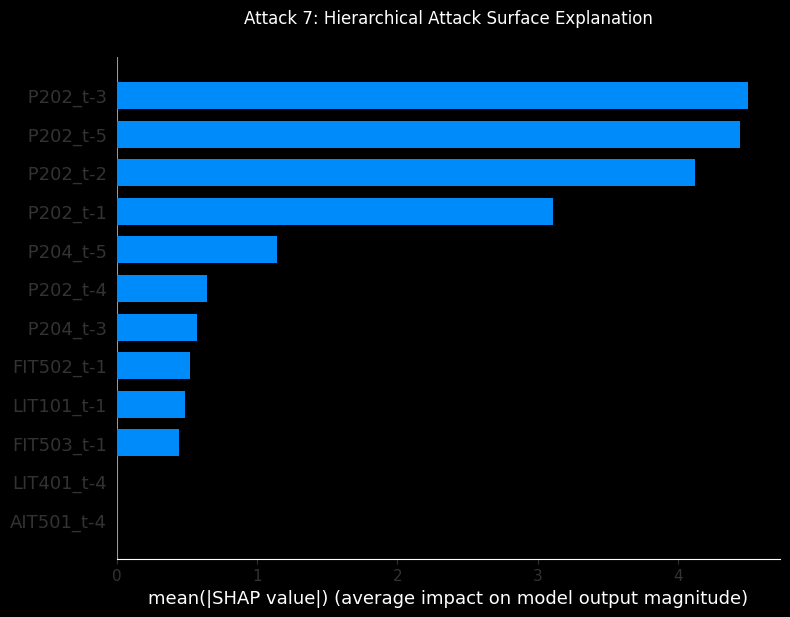

Processing attack 8/10 (index=10)...


  0%|          | 0/1 [00:00<?, ?it/s]

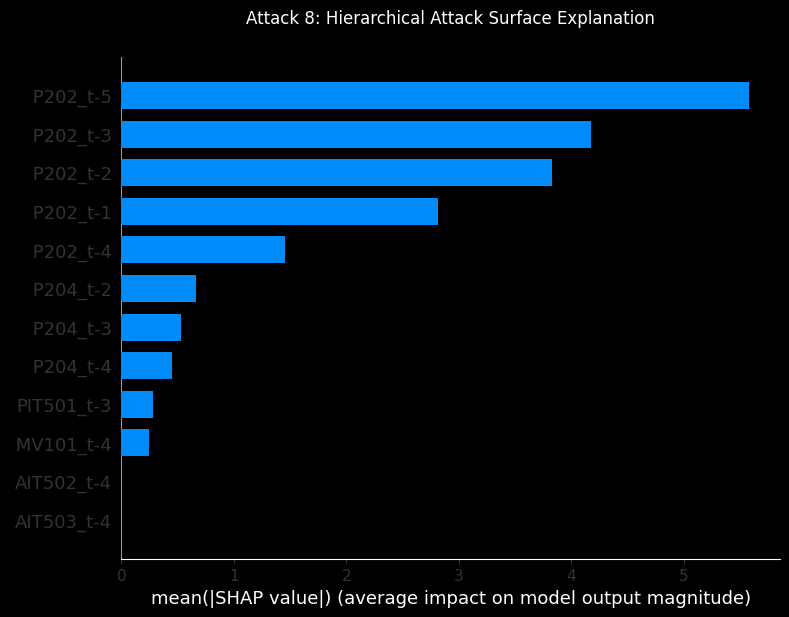

Processing attack 9/10 (index=11)...


  0%|          | 0/1 [00:00<?, ?it/s]

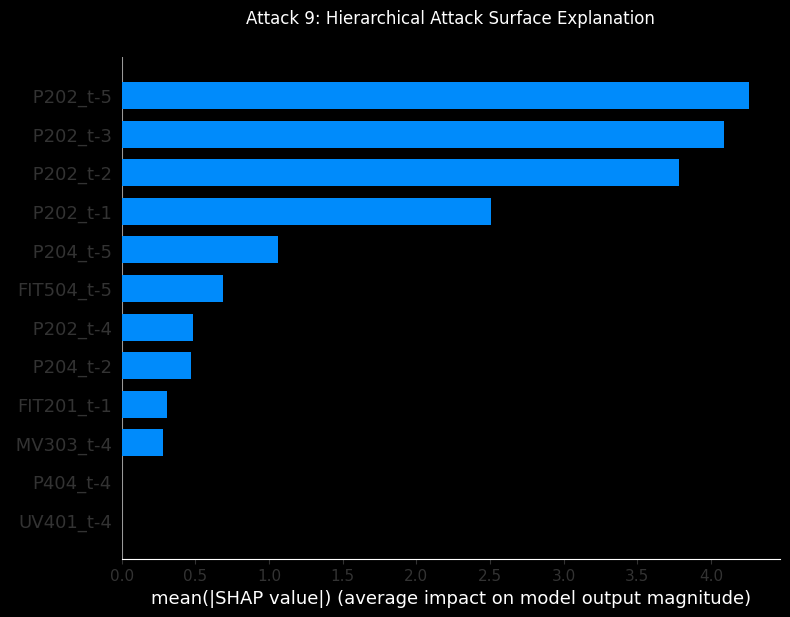

Processing attack 10/10 (index=12)...


  0%|          | 0/1 [00:00<?, ?it/s]

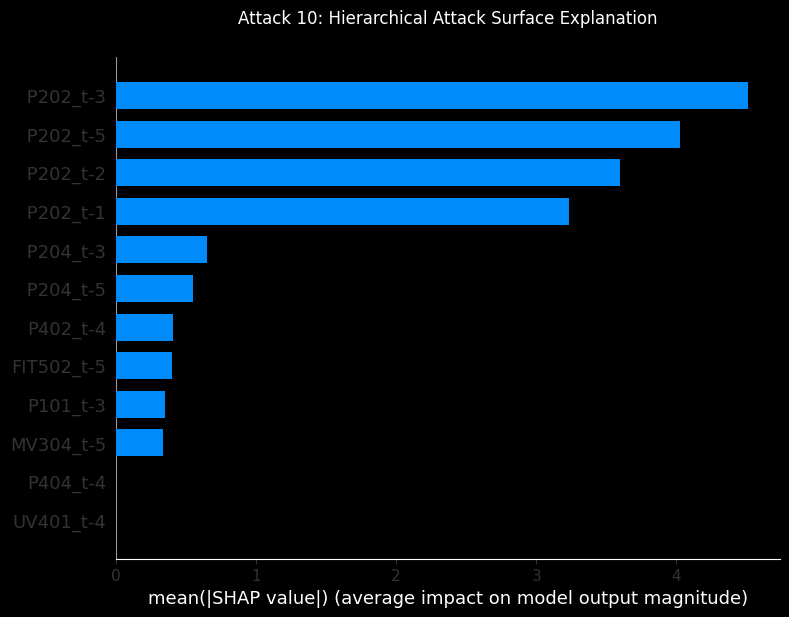


=== ALL ATTACK EXPLANATIONS COMPLETE ===


In [26]:
print("Initializing SHAP for Attack Surface Explainability...")

def lstm_wrapper(x_2d):
    x_3d = x_2d.reshape(-1, SEQ_LENGTH, len(SENSOR_COLUMNS))
    preds = defender.predict(x_3d, verbose=0)
    return np.mean(np.square(x_3d - preds), axis=(1, 2))

# Background data (keep small)
background = X_train_seq[:50].reshape(50, -1)
explainer = shap.KernelExplainer(lstm_wrapper, background)

# Feature names with time steps
seq_feature_names = [
    f"{feat}_t-{SEQ_LENGTH-i}"
    for i in range(SEQ_LENGTH)
    for feat in SENSOR_COLUMNS
]

print("Generating SHAP explanations for 10 attacks...\n")

# Limit to 10 attacks (or fewer if not enough exist)
num_attacks = min(10, len(attack_indices))

for i in range(num_attacks):
    idx = attack_indices[i]
    attack_sample = X_test_seq[idx:idx+1].reshape(1, -1)

    print(f"Processing attack {i+1}/{num_attacks} (index={idx})...")

    shap_values = explainer.shap_values(attack_sample)

    # Plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values,
        attack_sample,
        feature_names=seq_feature_names,
        plot_type="bar",
        max_display=12,
        show=False
    )
    plt.title(
        f"Attack {i+1}: Hierarchical Attack Surface Explanation",
        y=1.05
    )
    plt.tight_layout()
    plt.show()

print("\n=== ALL ATTACK EXPLANATIONS COMPLETE ===")